In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from Task7.main import prediction

In [13]:
df = pd.read_excel("car_sales.xlsx")

In [14]:
# 🧱 1. Dataset oxuma və ilkin analiz
print(df.head())
print("\n")
print(df.info())
print("\n")
print(df.describe())
print("\n")
print(df.isnull().sum())
print("\n")
print("Sutun tipleri\n",df.dtypes)

        Brand  ModelYear  EngineSize_L FuelType Transmission  Mileage_km  \
0     Renault     2008.0           2.1   Petrol    Automatic    111704.0   
1     Peugeot     2008.0           2.7   Diesel       Manual    105950.0   
2  Volkswagen     2006.0           2.7   Petrol    Automatic    166046.0   
3      Toyota     2022.0           2.1   Petrol    Automatic     92194.0   
4    Mercedes     2019.0           1.9   Diesel       Manual      5203.0   

   Seats  Price_AZN  
0      4       5000  
1      4       8500  
2      5       5000  
3      5      20122  
4      2      41513  


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         1000 non-null   str    
 1   ModelYear     965 non-null    float64
 2   EngineSize_L  966 non-null    float64
 3   FuelType      973 non-null    str    
 4   Transmission  1000 non-null   str    
 5   Mileage_k

In [19]:
# 🧩 2. Preprocessing
X = df.drop("Price_AZN", axis=1)
y = df["Price_AZN"]

num_cols = [
    "ModelYear",
    "EngineSize_L",
    "Mileage_km",
    "Seats"
]

cat_cols = [
    "Brand",
    "FuelType",
    "Transmission"
]

numeric_transformer=Pipeline(steps=[
                                ('imputer',SimpleImputer(strategy='median')),
                                ('scaler',StandardScaler())
                                ]
                            )
categorical_transformer=Pipeline(steps=[
                                ('imputer',SimpleImputer(strategy='most_frequent')),
                                ('encoder',OneHotEncoder(handle_unknown='ignore'))
                                ]
                            )

preprocessor=ColumnTransformer(
   transformers=[
       ('num',numeric_transformer,num_cols),
       ('cat',categorical_transformer,cat_cols)
   ]
)

# ⚙️ 3. Multi-variable regression model
model=Pipeline(steps=[
   ('preprocessor',preprocessor),
   ('regressor',LinearRegression())
])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 📈 4. Modeli öyrət və nəticə çıxart
model.fit(X_train,y_train)
pred=model.predict(X_test)
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
r2=r2_score(y_test,pred)

print("MAE:",mae)
print("MSE",mse)
print("R2",r2)


MAE: 3360.37554420006
MSE 33734811.94973703
R2 0.7488907130611198


In [20]:
# 🧮 5. “Feature importance” analizi
encoder = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
encoded_features = encoder.get_feature_names_out(cat_cols)
feature_names = num_cols + list(encoded_features)

importances = pd.Series(model.named_steps["regressor"].coef_, index=feature_names)
print(importances.sort_values(ascending=False).head(10))

Brand_Mercedes            13447.368449
Brand_BMW                 11585.395485
Brand_Audi                 9958.102521
ModelYear                  5024.982118
FuelType_Electric          1991.929704
EngineSize_L               1735.739893
FuelType_Hybrid             522.421199
Transmission_Automatic      423.166105
Seats                       210.330242
Transmission_Manual        -423.166105
dtype: float64


In [24]:
# 🧠 6. Mini console tətbiqi
brand = input("Marka (Toyota, BMW, Kia...): ")
year = int(input("Buraxılış ili: "))
engine = float(input("Mühərrik həcmi (L): "))
fuel = input("Yanacaq növü (Petrol, Diesel, Hybrid, Electric): ")
trans = input("Transmissiya (Automatic, Manual): ")
mileage = int(input("Yürüş (km): "))
seats = int(input("Oturacaq sayı: "))

new_car = pd.DataFrame({
    "Brand": [brand],
    "ModelYear": [year],
    "EngineSize_L": [engine],
    "FuelType": [fuel],
    "Transmission": [trans],
    "Mileage_km": [mileage],
    "Seats": [seats]
})
prediction = model.predict(new_car)
print("Brand:", brand)
print("ModelYear:", year)
print("EngineSize_L:", engine)
print("FuelType:", fuel)
print("Transmission:", trans)
print("Mileage_km:", mileage)
print("Seats:", seats)
print(f"📊 Təxmin edilən satış qiyməti: {prediction[0]:,.0f} AZN")

Brand: BMW
ModelYear: 2020
EngineSize_L: 2.0
FuelType: Petrol
Transmission: Automatic
Mileage_km: 50000
Seats: 5
📊 Təxmin edilən satış qiyməti: 36,114 AZN


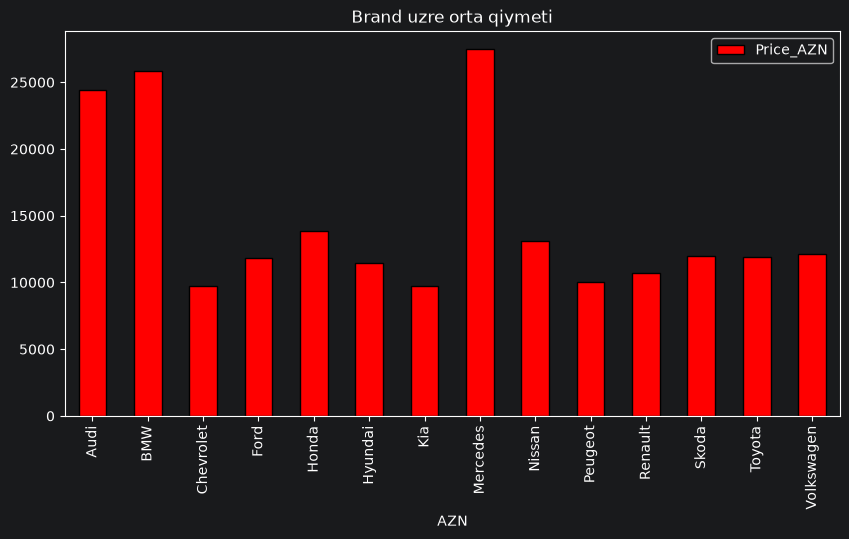

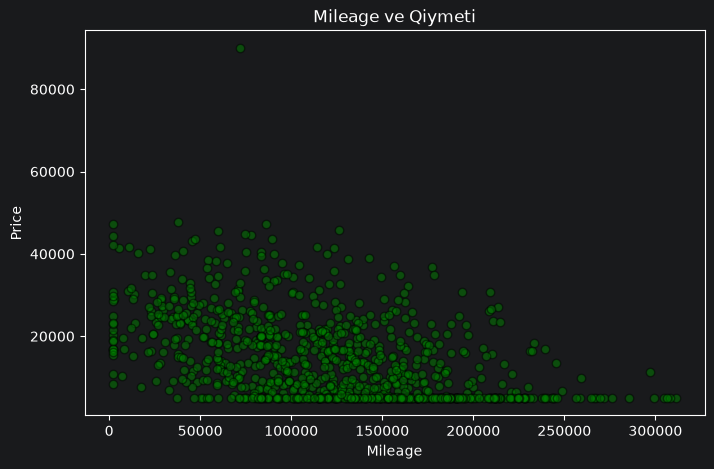

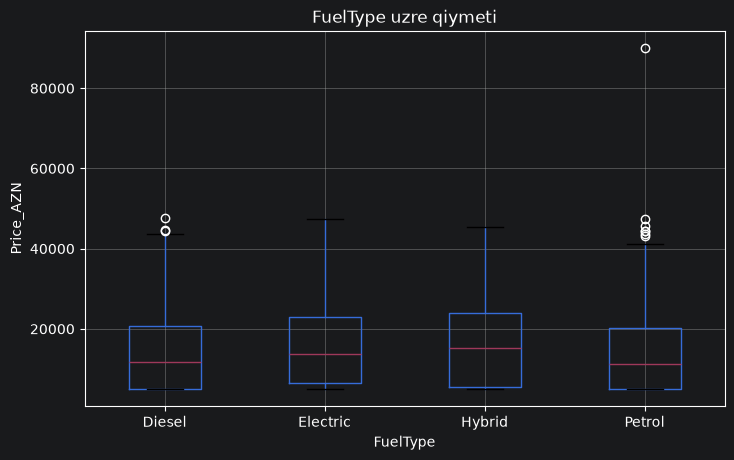

In [52]:
# 📊 7. Qrafiklərlə analiz

# Brand uzre orta qiymeti
df.groupby("Brand")["Price_AZN"].mean().plot(kind="bar",figsize=(10,5),color="red",edgecolor="black",legend=True)
plt.title("Brand uzre orta qiymeti")
plt.xlabel("AZN")
plt.show()

# Milage ve Qiymeti
plt.figure(figsize=(8,5))
plt.title("Mileage ve Qiymeti")
plt.scatter(df["Mileage_km"], df["Price_AZN"], c="green", alpha=0.5, edgecolor="black")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()


# FuelType uzre qiymətlər
df.boxplot(column="Price_AZN", by="FuelType", figsize=(8,5))
plt.title("FuelType uzre qiymeti")
plt.suptitle("")   # pandas-in avtomatik basligini silir
plt.xlabel("FuelType")
plt.ylabel("Price_AZN")
plt.show()

In [53]:
# 💬 8. Mini Report sualları:
print("1.Hansı faktor qiymətə ən çox təsir edir? \nFeature importance nəticəsinə görə ən böyük əmsala malik faktor qiymətə ən çox təsir edir.")
print("2.Mühərrik ölçüsü və yürüş arasında əlaqə varmı? \nBəli, müəyyən əlaqə ola bilər, lakin bu datasetdən asılıdır.")
print("3.R² nəticəsi modelin keyfiyyətini necə göstərir? \nR² nə qədər 1-ə yaxın olsa, model bir o qədər dəqiq proqnoz verir.")
print("4.Hansı preprocessing addımı ən vacib idi və niyə? \nOneHotEncoder və boş dəyərlərin doldurulması vacib idi, çünki model mətn məlumatları və boş dəyərlərlə işləyə bilmir.")
print("5.Bu modeli gələcəkdə necə inkişaf etdirmək olar? \nDaha çox məlumat əlavə etmək və RandomForest və ya XGBoost kimi daha güclü modellərdən istifadə etməklə.")

1.Hansı faktor qiymətə ən çox təsir edir? 
Feature importance nəticəsinə görə ən böyük əmsala malik faktor qiymətə ən çox təsir edir.
2.Mühərrik ölçüsü və yürüş arasında əlaqə varmı? 
Bəli, müəyyən əlaqə ola bilər, lakin bu datasetdən asılıdır.
3.R² nəticəsi modelin keyfiyyətini necə göstərir? 
R² nə qədər 1-ə yaxın olsa, model bir o qədər dəqiq proqnoz verir.
4.Hansı preprocessing addımı ən vacib idi və niyə? 
OneHotEncoder və boş dəyərlərin doldurulması vacib idi, çünki model mətn məlumatları və boş dəyərlərlə işləyə bilmir.
5.Bu modeli gələcəkdə necə inkişaf etdirmək olar? 
Daha çox məlumat əlavə etmək və RandomForest və ya XGBoost kimi daha güclü modellərdən istifadə etməklə.
